<a href="https://colab.research.google.com/github/jane-kirina/python_for_ds_and_ml_tasks/blob/main/module_2/topic_2/HW_2_2_2_LogReg_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

# Завдання 1

## Завантаження даних

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/_DLA_/module_2/topic_2/kaggle_competition/data/"

import pandas as pd
train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
sample_submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Зчитання даних

> Зчитайте дані train.csv в pandas dataframe та розбийте їх на train і validation піднабори.
>
> Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.


In [2]:
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
X = train.drop('Exited', axis=1)
y = train['Exited']

from sklearn.model_selection import train_test_split

# Note: stratify=y, бо якщо клас `Exited=1` зустрічається рідко (~20%),
#   без stratify validation може випадково отримати 10% або 30%, і модель буде оцінена неправильно
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
print('Train class distribution:')
print(y_train.value_counts(normalize=True))

Train class distribution:
Exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64


In [5]:
print('Validation class distribution:')
print(y_val.value_counts(normalize=True))

Validation class distribution:
Exited
0.0    0.796667
1.0    0.203333
Name: proportion, dtype: float64


# Завдання 2

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [6]:
target_col = 'Exited'
# Прибираємо колонкі, які не потрібні для навчання
drop_cols = ['id', 'CustomerId', 'Surname']

input_cols = [col for col in train.columns if col != target_col and col not in drop_cols]

train_inputs = X_train[input_cols]
train_targets = y_train

val_inputs = X_val[input_cols]
val_targets = y_val

print(f'Train input shape: {train_inputs.shape}')
print(f'Train targets shape: {train_targets.shape}')

print(f'Validation input shape: {val_inputs.shape}')
print(f'Validation targets shape: {val_targets.shape}')

Train input shape: (12000, 10)
Train targets shape: (12000,)
Validation input shape: (3000, 10)
Validation targets shape: (3000,)


In [7]:
input_cols # no 'Exited', features for trainning model

['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

# Завдання 3

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [9]:
numeric_cols = train_inputs.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols =  train_inputs.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns: {numeric_cols}')
print(f'Categorical columns: {categorical_cols}')

Numeric columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical columns: ['Geography', 'Gender']


# Завдання 4

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [11]:
# Pipelines для типів ознак
# Числові ознаки
numeric_transformer = Pipeline(steps=[
    # якщо є пропуски, заповняємо по медіані, краще для фінансових даних + стійка до викидів (outliers)
    ('smputer', SimpleImputer(strategy='median')),
    # масштабування: приводимо всі числові колонки до одного масштабу
    ('scaler', StandardScaler())
])

# Категоріальні ознаки
categorical_transformer = Pipeline(steps=[
    # замінює на найпопулярнішу категорію
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # кодування, бо модель не працює з текстом
    # sparse_output - для виводу через display()
    # sparse_output=False - потрібен для отримання dense DataFrame у pandas
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [12]:
# ColumnTransformer: об’єднуємо в один препроцесор
# numeric pipeline -> numeric_cols,
# categorical pipeline -> categorical_cols
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [13]:
# Перетворення результату у pandas DataFrame

# set_output(transform="pandas") дозволяє отримати результат як DataFrame
preprocessor.set_output(transform='pandas')

# fit_transform робимо тільки на train, щоб уникнути data leakage
train_inputs_prep = preprocessor.fit_transform(train_inputs)
# transform застосовуємо до validation
val_inputs_prep = preprocessor.transform(val_inputs)

In [14]:
from IPython.display import display
# Перевірка результату виведіть по 5 значен
display(train_inputs_prep.head(5))
display(val_inputs_prep.head(5))

,num__CreditScore,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__EstimatedSalary,cat__Geography_France,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Female,cat__Gender_Male
7180,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,1.0,0.0,0.0,0.0,1.0
10393,0.347838,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,1.0,0.0,0.0,1.0,0.0
80,0.638166,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,0.0,1.0,0.0,0.0,1.0
3365,0.140460,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,0.0,0.0,1.0,0.0,1.0
12236,0.665816,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,1.0,0.0,0.0,0.0,1.0


,num__CreditScore,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__EstimatedSalary,cat__Geography_France,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Female,cat__Gender_Male
6490,0.762592,1.021379,-1.447264,1.214543,4.524299,0.515062,1.016977,-0.988144,0.0,1.0,0.0,0.0,1.0
3646,-0.910252,0.406985,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.750392,1.0,0.0,0.0,0.0,1.0
5306,0.997620,0.038348,-1.087792,-0.717950,0.769304,-1.941514,1.016977,-0.022404,1.0,0.0,0.0,1.0,0.0
652,0.195761,0.652742,-0.368848,1.881867,-1.108193,-1.941514,1.016977,-0.139723,1.0,0.0,0.0,1.0,0.0
2627,0.264887,-0.944682,-0.368848,-0.717950,0.769304,0.515062,-0.983306,0.563519,0.0,0.0,1.0,1.0,0.0


# Завдання 5

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [15]:
!pip install pyarrow --quiet

In [16]:
import os

# save_dir = "/content/drive/MyDrive/Colab Notebooks/_DLA_/module_2/topic_2/kaggle_competition/data_parquet"
save_dir = 'data_parquet'
os.makedirs(save_dir, exist_ok=True)

# Inputs (DataFrame)
train_inputs.to_parquet(f'{save_dir}/train_inputs.parquet')
val_inputs.to_parquet(f'{save_dir}/val_inputs.parquet')

# Targets (Series перетворуємо у DataFrame)
train_targets.to_frame().to_parquet(f'{save_dir}/train_targets.parquet')
val_targets.to_frame().to_parquet(f'{save_dir}/val_targets.parquet')

print('Saved:')
print(os.listdir(save_dir))

Saved:
['train_inputs.parquet', 'val_inputs.parquet', 'val_targets.parquet', 'train_targets.parquet']


In [17]:
!ls "/content/data_parquet"

train_inputs.parquet   val_inputs.parquet
train_targets.parquet  val_targets.parquet


# Завдання 6

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, f1_score, roc_auc_score, average_precision_score, precision_recall_curve)
import matplotlib.pyplot as plt

X_train = train_inputs_prep
X_val   = val_inputs_prep

y_train = train_targets
y_val   = val_targets

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [20]:

train_pred = log_reg.predict(X_train)
val_pred   = log_reg.predict(X_val)

train_proba = log_reg.predict_proba(X_train)[:, 1]
val_proba   = log_reg.predict_proba(X_val)[:, 1]

# Завдання 7

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

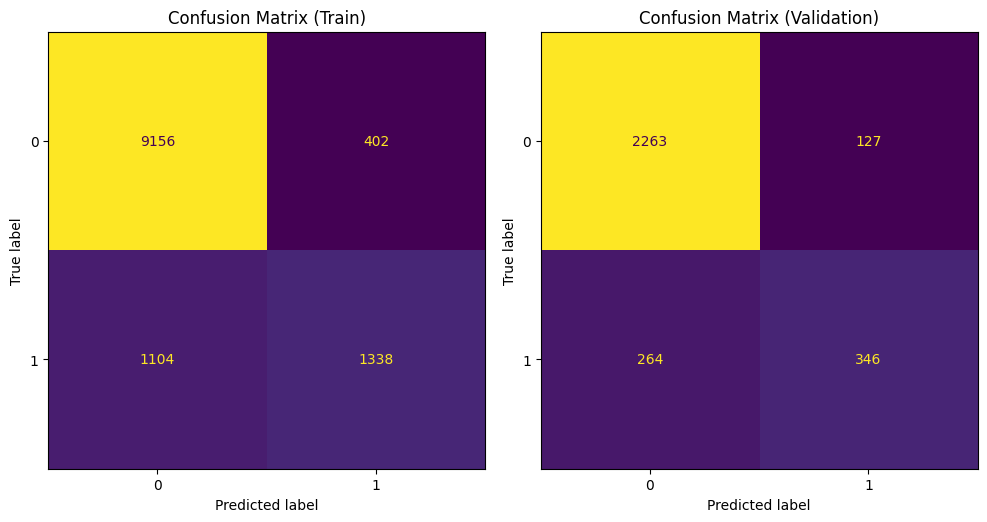

In [21]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# Train
cm_train = confusion_matrix(train_targets, train_pred)
ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Train)')

# Validation
cm_val = confusion_matrix(val_targets, val_pred)
ConfusionMatrixDisplay(cm_val).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix (Validation)')

plt.tight_layout()
plt.show()

In [22]:
# AUROC + F1 Score
# AUROC
train_auc = roc_auc_score(train_targets, train_proba)
val_auc = roc_auc_score(val_targets, val_proba)

# F1 Score
train_f1 = f1_score(train_targets, train_pred)
val_f1 = f1_score(val_targets, val_pred)

print(f'Train AUROC: {train_auc}')
print(f'Validation AUROC: {val_auc}')

print(f'Train F1: {train_f1}')
print(f'Validation F1: {val_f1}')


Train AUROC: 0.8825410327293567
Validation AUROC: 0.8796515536044996
Train F1: 0.6398852223816356
Validation F1: 0.6389658356417359


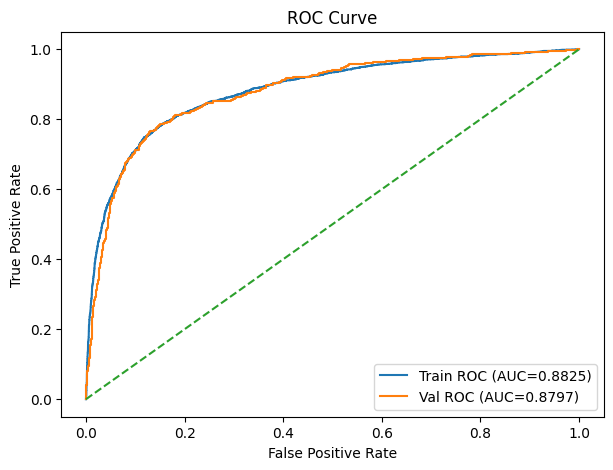

In [23]:
# ROC curve values
fpr_train, tpr_train, _ = roc_curve(train_targets, train_proba)
fpr_val, tpr_val, _ = roc_curve(val_targets, val_proba)

plt.figure(figsize=(7,5))

plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC={train_auc:.4f})')
plt.plot(fpr_val, tpr_val, label=f'Val ROC (AUC={val_auc:.4f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Results
Модель добре ловить клас **0 (більшість)**, але **частину клієнтів з `Exited=1` пропускає** (тобто FN досить багато)

## Confusion Matrix

### Train

| True \ Predicted | 0 (Not Exited) | 1 (Exited) |
|------------------|---------------|------------|
| **0 (Not Exited)** | **TN = 9156** | **FP = 402** |
| **1 (Exited)**     | **FN = 1104** | **TP = 1338** |


### Validation

| True \ Predicted | 0 (Not Exited) | 1 (Exited) |
|------------------|---------------|------------|
| **0 (Not Exited)** | **TN = 2263** | **FP = 127** |
| **1 (Exited)**     | **FN = 264**  | **TP = 346** |

## AUROC
- **Train AUROC = 0.883**  
- **Validation AUROC = 0.880**

AUROC суттєво більше за 0.5, криві train/val майже однакові ->
**перенавчання мінімальне**

## F1-score (threshold = 0.5)
- **Train F1 = 0.640**  
- **Validation F1 = 0.639**

F1 стабільний між train і val -> модель узагальнює нормально

## Висновок
Модель є **задовільною як baseline**.

Плюси моделі:
- високе **AUROC ≈ 0.88**
- майже однакові метрики на train/val
- модель **стабільна**, без явного overfitting

Мінуси моделі:
- при порозі 0.5 **recall не дуже високий**
- модель **пропускає частину клієнтів, які підуть** (FN)



# Завдання 8

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, train_targets)

train_pred_dummy = dummy.predict(X_train)
val_pred_dummy = dummy.predict(X_val)

train_acc_dummy = accuracy_score(train_targets, train_pred_dummy)
val_acc_dummy = accuracy_score(val_targets, val_pred_dummy)

print(f'Majority Train Accuracy: {train_acc_dummy:.4f}')
print(f'Majority Val Accuracy:   {val_acc_dummy:.4f}')

# Accuracy for Logistic Regression model - task 6
train_pred_lr = log_reg.predict(X_train)
val_pred_lr = log_reg.predict(X_val)

train_acc_lr = accuracy_score(train_targets, train_pred_lr)
val_acc_lr = accuracy_score(val_targets, val_pred_lr)

print(f'LogReg Train Accuracy: {train_acc_lr:.4f}')
print(f'LogReg Val Accuracy: {val_acc_lr:.4f}')

Majority Train Accuracy: 0.7965
Majority Val Accuracy:   0.7967
LogReg Train Accuracy: 0.8745
LogReg Val Accuracy: 0.8697


In [25]:
results = pd.DataFrame({
    'Model': ['Majority', 'Logistic Regression'],
    'Train Accuracy': [train_acc_dummy, train_acc_lr],
    'Val Accuracy': [val_acc_dummy, val_acc_lr]
})

results

,Model,Train Accuracy,Val Accuracy
0,Majority,0.7965,0.796667
1,Logistic Regression,0.8745,0.869667


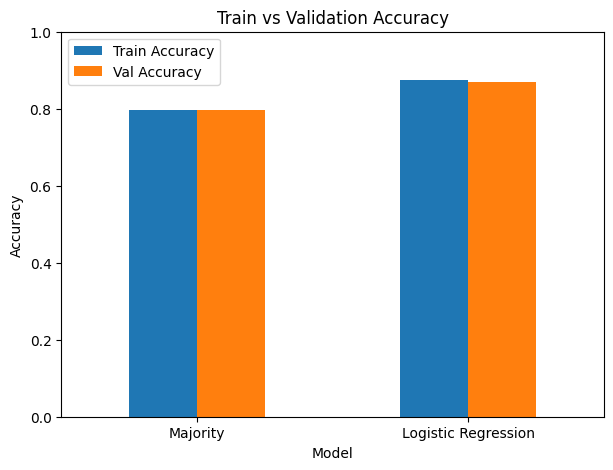

In [26]:
results.set_index('Model').plot(kind='bar', figsize=(7,5))

plt.title('Train vs Validation Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

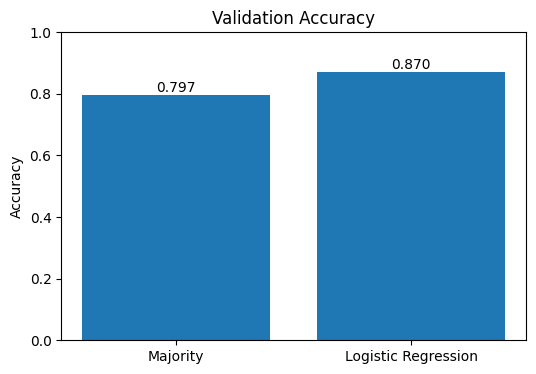

In [27]:
plt.figure(figsize=(6,4))

bars = plt.bar(results['Model'], results['Val Accuracy'])

plt.title('Validation Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{height:.3f}', ha='center')

plt.show()

## Accuracy

| Model               | Train Accuracy | Val Accuracy |
| ------------------- | -------------: | -----------: |
| Majority baseline   |         0.7965 |       0.7967 |
| Logistic Regression |         0.8745 |       0.8697 |


- Baseline majority модель, яка завжди прогнозує найчастіший клас, показує Accuracy ~ 0.80 на train і validation. Такий результат можно пояснити дисбалансом класів, оскільки більшість клієнтів у датасеті не залишають банк
- Logistic Regression покращує якість моделі:
Validation Accuracy зростає до ~ 0.87
- Датасет незбалансований (Exited=1 зустрічається рідше), тому accuracy може бути 'високою'. Тому для задачі треба також дивитися на AUROC та F1

**Якість побудованої моделі можна оцінити як хорошу**. Модель добре відокремлює клієнтів з ризиком відтоку (AUROC). FN вдвічі більше, ніж FP, при 0.5 recall для класу 1 не ідеальний, і якщо бізнесу важливіше 'не пропустити того, хто піде' - то поріг треба рухати в бік зменшення FN (але FP тоді виросте)



# Завдання 9

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [28]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', log_reg)
])

pipeline.fit(train_inputs, train_targets)

joblib.dump(pipeline, 'log_reg.joblib')
model_2 = joblib.load('log_reg.joblib')
val_proba_loaded = model_2.predict_proba(val_inputs)[:, 1]
print(f'Model AUROC: {roc_auc_score(val_targets, val_proba_loaded)}')

Model AUROC: 0.8796515536044996


> Збережено повний pipeline (preprocessing + model), щоб можна було робити predictions на сирих даних

# Завдання 10

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [29]:
import warnings
warnings.filterwarnings("ignore")

# scaler і encoder нема, бо вони всередині preprocessor
'''
def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob
'''
# Метод ьуде працювати через ColumnTransformer та Pipeline
def predict_raw_df(model_pipeline, input_df: pd.DataFrame):
    '''
    Приймає сирий DataFrame (до preprocessing)
    Додає прогноз моделі до таблиці
    Повертає ймовірності класу 1 (Exited=1)
    '''
    proba = model_pipeline.predict_proba(input_df)[:, 1]

    result = input_df.copy()
    result['Exited_Probability'] = proba

    return result


In [32]:
# predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, raw_df[:5])

probs = predict_raw_df(model_2, val_inputs[:5])

print("Probabilities of Exited=1:")
print(probs)

Probabilities of Exited=1:
      CreditScore Geography  Gender   Age  Tenure    Balance  NumOfProducts  \
6490        714.0   Germany    Male  46.0     1.0  115764.32            4.0   
3646        593.0    France    Male  41.0     5.0       0.00            2.0   
5306        731.0    France  Female  38.0     2.0       0.00            2.0   
652         673.0    France  Female  43.0     4.0  155739.76            1.0   
2627        678.0     Spain  Female  30.0     4.0       0.00            2.0   

      HasCrCard  IsActiveMember  EstimatedSalary  Exited_Probability  
6490        1.0             1.0         72945.32            0.013190  
3646        1.0             1.0         38196.24            0.040359  
5306        0.0             1.0        116971.05            0.058592  
652         0.0             1.0        111622.76            0.202352  
2627        1.0             0.0        143681.85            0.050742  


# Завдання 11

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [41]:
test_raw_df = pd.read_csv(DATA_PATH + 'test.csv')

print('Test shape', test_raw_df.shape)
display(test_raw_df.head())

test_raw_df['Exited'] = model_2.predict(test_raw_df)
display(test_raw_df.head())

Test shape (10000, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.0
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.0
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.0
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.0
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.0


In [42]:
test_raw_df[['Exited']].to_csv('submission.csv', index=False)
print('Saved')

Saved


# Завдання 12

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [51]:
import os
print(os.listdir())

['.config', 'drive', 'data_parquet', 'submission.csv', 'log_reg.joblib', 'sample_data']


In [48]:
submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')
submission['Exited'] = model_2.predict(test_raw_df)
display(submission.head())
submission.to_csv(DATA_PATH + 'submission_log_reg.csv', index=False)

print('Saved')

,id,Exited
0,15000,0.0
1,15001,0.0
2,15002,0.0
3,15003,0.0
4,15004,0.0


Saved


In [50]:
# check
print(submission.columns)
print(submission['Exited'].value_counts())

Index(['id', 'Exited'], dtype='object')
Exited
0.0    8429
1.0    1571
Name: count, dtype: int64
